# Amazon Advertising Keyword Analysis

## Business Problem

An Amazon seller wants to optimise their advertising campaigns.

The goal is to analyse keyword performance and determine which keywords should be:

• scaled  
• optimised  
• paused  

The dataset contains keyword-level advertising data including clicks, spend, orders and sales.

## Dataset Overview

The dataset contains advertising performance for Amazon keywords including:

- Clicks
- Spend
- Orders
- Sales

This project simulates advertising data for analysis purposes.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

keywords = [
"bluetooth speaker","portable speaker","loud bluetooth speaker","mini speaker",
"wireless speaker","party speaker","waterproof speaker","bass speaker",
"speaker for travel","cheap bluetooth speaker"
]

data = []

for i in range(120):
    
    keyword = np.random.choice(keywords)
    
    clicks = np.random.randint(20,300)
    
    spend = round(clicks * np.random.uniform(0.6,1.5),2)
    
    orders = np.random.randint(0,30)
    
    sales = round(orders * np.random.uniform(25,80),2)
    
    data.append([keyword,clicks,spend,orders,sales])

df = pd.DataFrame(data,columns=["Keyword","Clicks","Spend","Orders","Sales"])

df

,Keyword,Clicks,Spend,Orders,Sales
0,waterproof speaker,290,365.05,28,1619.15
1,cheap bluetooth speaker,234,152.63,23,997.14
2,bass speaker,171,202.77,20,1566.90
3,party speaker,211,315.02,0,0.00
4,party speaker,272,268.94,16,861.80
...,...,...,...,...,...
115,wireless speaker,27,20.32,3,151.51
116,cheap bluetooth speaker,197,165.35,4,314.37
117,party speaker,164,139.69,20,1395.17
118,loud bluetooth speaker,272,393.44,18,1168.46


## Data Cleaning

The dataset is cleaned by:

• removing duplicates  
• removing missing values  

In [2]:
df.loc[5,"Sales"] = np.nan
df.loc[12,"Orders"] = np.nan
df.loc[25,"Clicks"] = np.nan

df = pd.concat([df, df.iloc[[10]]])  # duplicate row

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121 entries, 0 to 10
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Keyword  121 non-null    object 
 1   Clicks   120 non-null    float64
 2   Spend    121 non-null    float64
 3   Orders   120 non-null    float64
 4   Sales    120 non-null    float64
dtypes: float64(4), object(1)
memory usage: 5.7+ KB


In [4]:
df.isna().sum()

Keyword    0
Clicks     1
Spend      0
Orders     1
Sales      1
dtype: int64

In [5]:
df = df.drop_duplicates()

In [6]:
df = df.dropna()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117 entries, 0 to 119
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Keyword  117 non-null    object 
 1   Clicks   117 non-null    float64
 2   Spend    117 non-null    float64
 3   Orders   117 non-null    float64
 4   Sales    117 non-null    float64
dtypes: float64(4), object(1)
memory usage: 5.5+ KB


## Feature Engineering

Additional advertising metrics are calculated:

• CPC (Cost Per Click)  
• Conversion Rate  
• ACOS (Advertising Cost of Sales)  
• ROAS (Return on Ad Spend)

In [8]:
df["CPC"] = df["Spend"] / df["Clicks"]

df["Conversion_Rate"] = df["Orders"] / df["Clicks"]

df["ACOS"] = df["Spend"] / df["Sales"]

df["ROAS"] = df["Sales"] / df["Spend"]

df.head()

,Keyword,Clicks,Spend,Orders,Sales,CPC,Conversion_Rate,ACOS,ROAS
0,waterproof speaker,290.0,365.05,28.0,1619.15,1.258793,0.096552,0.225458,4.435420
1,cheap bluetooth speaker,234.0,152.63,23.0,997.14,0.652265,0.098291,0.153068,6.533054
2,bass speaker,171.0,202.77,20.0,1566.90,1.185789,0.116959,0.129408,7.727474
3,party speaker,211.0,315.02,0.0,0.00,1.492986,0.000000,inf,0.000000
4,party speaker,272.0,268.94,16.0,861.80,0.988750,0.058824,0.312068,3.204432


## Keyword Performance Analysis

Keyword performance is aggregated to understand overall campaign effectiveness.

In [9]:
keyword_summary = df.groupby("Keyword").sum(numeric_only=True)

keyword_summary

,Clicks,Spend,Orders,Sales,CPC,Conversion_Rate,ACOS,ROAS
Keyword,,,,,,,,
bass speaker,1005.0,1121.37,97.0,5977.11,7.826996,0.781280,2.069380,45.758380
bluetooth speaker,2709.0,3152.22,195.0,9746.03,18.167821,1.338576,8.600796,61.987160
cheap bluetooth speaker,2134.0,2059.62,108.0,4326.67,10.662616,0.809603,inf,34.600941
loud bluetooth speaker,2263.0,2418.81,178.0,10181.89,14.878079,1.344782,inf,77.857187
mini speaker,2131.0,2229.53,240.0,13410.17,14.220299,4.596922,inf,332.968633
party speaker,2574.0,2921.88,229.0,10835.84,15.434584,1.645351,inf,73.697416
portable speaker,1234.0,1278.95,99.0,4564.28,8.572477,0.794101,4.771219,32.030049
speaker for travel,1821.0,1845.74,142.0,5798.50,14.000599,1.588017,inf,55.074351
waterproof speaker,1664.0,1667.17,172.0,10596.68,8.837234,1.534786,4.745391,110.311753


In [10]:
keyword_summary.sort_values(by="Sales", ascending=False)

,Clicks,Spend,Orders,Sales,CPC,Conversion_Rate,ACOS,ROAS
Keyword,,,,,,,,
mini speaker,2131.0,2229.53,240.0,13410.17,14.220299,4.596922,inf,332.968633
party speaker,2574.0,2921.88,229.0,10835.84,15.434584,1.645351,inf,73.697416
waterproof speaker,1664.0,1667.17,172.0,10596.68,8.837234,1.534786,4.745391,110.311753
loud bluetooth speaker,2263.0,2418.81,178.0,10181.89,14.878079,1.344782,inf,77.857187
bluetooth speaker,2709.0,3152.22,195.0,9746.03,18.167821,1.338576,8.600796,61.987160
wireless speaker,1343.0,1396.22,161.0,8971.82,11.373199,1.761899,1.816999,98.263107
bass speaker,1005.0,1121.37,97.0,5977.11,7.826996,0.781280,2.069380,45.758380
speaker for travel,1821.0,1845.74,142.0,5798.50,14.000599,1.588017,inf,55.074351
portable speaker,1234.0,1278.95,99.0,4564.28,8.572477,0.794101,4.771219,32.030049


In [11]:
keyword_summary.sort_values(by="Spend", ascending=False)

,Clicks,Spend,Orders,Sales,CPC,Conversion_Rate,ACOS,ROAS
Keyword,,,,,,,,
bluetooth speaker,2709.0,3152.22,195.0,9746.03,18.167821,1.338576,8.600796,61.987160
party speaker,2574.0,2921.88,229.0,10835.84,15.434584,1.645351,inf,73.697416
loud bluetooth speaker,2263.0,2418.81,178.0,10181.89,14.878079,1.344782,inf,77.857187
mini speaker,2131.0,2229.53,240.0,13410.17,14.220299,4.596922,inf,332.968633
cheap bluetooth speaker,2134.0,2059.62,108.0,4326.67,10.662616,0.809603,inf,34.600941
speaker for travel,1821.0,1845.74,142.0,5798.50,14.000599,1.588017,inf,55.074351
waterproof speaker,1664.0,1667.17,172.0,10596.68,8.837234,1.534786,4.745391,110.311753
wireless speaker,1343.0,1396.22,161.0,8971.82,11.373199,1.761899,1.816999,98.263107
portable speaker,1234.0,1278.95,99.0,4564.28,8.572477,0.794101,4.771219,32.030049


In [12]:
keyword_summary.sort_values(by="Orders", ascending=False)

,Clicks,Spend,Orders,Sales,CPC,Conversion_Rate,ACOS,ROAS
Keyword,,,,,,,,
mini speaker,2131.0,2229.53,240.0,13410.17,14.220299,4.596922,inf,332.968633
party speaker,2574.0,2921.88,229.0,10835.84,15.434584,1.645351,inf,73.697416
bluetooth speaker,2709.0,3152.22,195.0,9746.03,18.167821,1.338576,8.600796,61.987160
loud bluetooth speaker,2263.0,2418.81,178.0,10181.89,14.878079,1.344782,inf,77.857187
waterproof speaker,1664.0,1667.17,172.0,10596.68,8.837234,1.534786,4.745391,110.311753
wireless speaker,1343.0,1396.22,161.0,8971.82,11.373199,1.761899,1.816999,98.263107
speaker for travel,1821.0,1845.74,142.0,5798.50,14.000599,1.588017,inf,55.074351
cheap bluetooth speaker,2134.0,2059.62,108.0,4326.67,10.662616,0.809603,inf,34.600941
portable speaker,1234.0,1278.95,99.0,4564.28,8.572477,0.794101,4.771219,32.030049


In [13]:
wasted_spend = df[df["Orders"] == 0]

wasted_spend[["Keyword","Clicks","Spend","Orders","Sales"]]

,Keyword,Clicks,Spend,Orders,Sales
3,party speaker,211.0,315.02,0.0,0.0
16,speaker for travel,176.0,232.67,0.0,0.0
31,party speaker,156.0,161.67,0.0,0.0
47,loud bluetooth speaker,171.0,164.85,0.0,0.0
52,mini speaker,154.0,192.32,0.0,0.0
73,speaker for travel,148.0,111.88,0.0,0.0
81,cheap bluetooth speaker,269.0,387.38,0.0,0.0
112,speaker for travel,33.0,28.55,0.0,0.0


In [14]:
wasted_spend["Spend"].sum()

np.float64(1594.34)

In [15]:
wasted_by_keyword = wasted_spend.groupby("Keyword")["Spend"].sum()

wasted_by_keyword.sort_values(ascending=False)

Keyword
party speaker              476.69
cheap bluetooth speaker    387.38
speaker for travel         373.10
mini speaker               192.32
loud bluetooth speaker     164.85
Name: Spend, dtype: float64

In [16]:
keyword_summary = df.groupby("Keyword").sum(numeric_only=True)

In [17]:
keyword_summary["CPC"] = keyword_summary["Spend"] / keyword_summary["Clicks"]

keyword_summary["Conversion_Rate"] = keyword_summary["Orders"] / keyword_summary["Clicks"]

keyword_summary["ACOS"] = keyword_summary["Spend"] / keyword_summary["Sales"]

keyword_summary["ROAS"] = keyword_summary["Sales"] / keyword_summary["Spend"]

In [19]:
keyword_summary.sort_values(by="Orders", ascending=False)

,Clicks,Spend,Orders,Sales,CPC,Conversion_Rate,ACOS,ROAS
Keyword,,,,,,,,
mini speaker,2131.0,2229.53,240.0,13410.17,1.046237,0.112623,0.166257,6.014797
party speaker,2574.0,2921.88,229.0,10835.84,1.135152,0.088967,0.269650,3.708516
bluetooth speaker,2709.0,3152.22,195.0,9746.03,1.163610,0.071982,0.323436,3.091799
loud bluetooth speaker,2263.0,2418.81,178.0,10181.89,1.068851,0.078657,0.237560,4.209463
waterproof speaker,1664.0,1667.17,172.0,10596.68,1.001905,0.103365,0.157329,6.356088
wireless speaker,1343.0,1396.22,161.0,8971.82,1.039628,0.119881,0.155623,6.425792
speaker for travel,1821.0,1845.74,142.0,5798.50,1.013586,0.077979,0.318313,3.141558
cheap bluetooth speaker,2134.0,2059.62,108.0,4326.67,0.965145,0.050609,0.476029,2.100713
portable speaker,1234.0,1278.95,99.0,4564.28,1.036426,0.080227,0.280208,3.568771


## Visualisation

Visualisations are used to identify high-performing and underperforming keywords.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6456\1286787075.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (keyword_summary["Spend"][i], keyword_summary["Conversion_Rate"][i]))


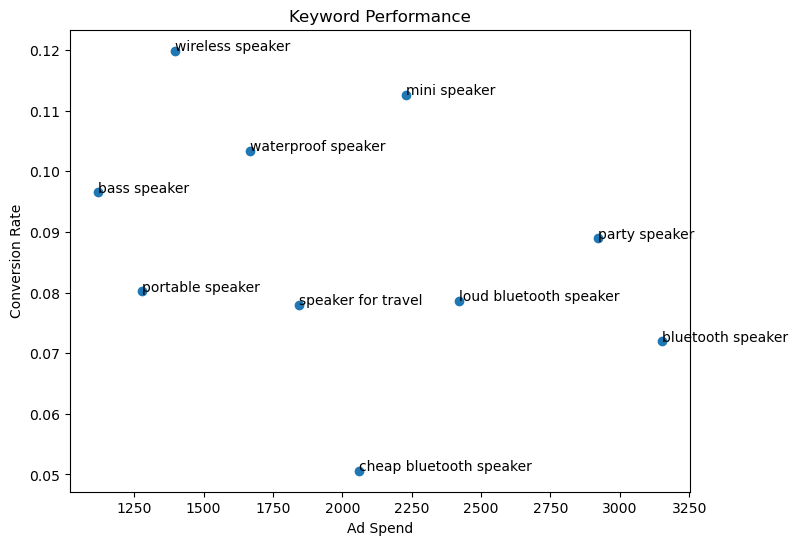

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(keyword_summary["Spend"], keyword_summary["Conversion_Rate"])

for i, txt in enumerate(keyword_summary.index):
    plt.annotate(txt, (keyword_summary["Spend"][i], keyword_summary["Conversion_Rate"][i]))

plt.xlabel("Ad Spend")
plt.ylabel("Conversion Rate")

plt.title("Keyword Performance")

plt.show()

In [21]:
def classify_keyword(row):
    
    if row["Conversion_Rate"] > 0.10:
        return "Scale"
    
    elif row["Conversion_Rate"] > 0.07:
        return "Optimise"
    
    else:
        return "Pause"

keyword_summary["Strategy"] = keyword_summary.apply(classify_keyword, axis=1)

keyword_summary

,Clicks,Spend,Orders,Sales,CPC,Conversion_Rate,ACOS,ROAS,Strategy
Keyword,,,,,,,,,
bass speaker,1005.0,1121.37,97.0,5977.11,1.115791,0.096517,0.187611,5.330185,Optimise
bluetooth speaker,2709.0,3152.22,195.0,9746.03,1.163610,0.071982,0.323436,3.091799,Optimise
cheap bluetooth speaker,2134.0,2059.62,108.0,4326.67,0.965145,0.050609,0.476029,2.100713,Pause
loud bluetooth speaker,2263.0,2418.81,178.0,10181.89,1.068851,0.078657,0.237560,4.209463,Optimise
mini speaker,2131.0,2229.53,240.0,13410.17,1.046237,0.112623,0.166257,6.014797,Scale
party speaker,2574.0,2921.88,229.0,10835.84,1.135152,0.088967,0.269650,3.708516,Optimise
portable speaker,1234.0,1278.95,99.0,4564.28,1.036426,0.080227,0.280208,3.568771,Optimise
speaker for travel,1821.0,1845.74,142.0,5798.50,1.013586,0.077979,0.318313,3.141558,Optimise
waterproof speaker,1664.0,1667.17,172.0,10596.68,1.001905,0.103365,0.157329,6.356088,Scale


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6456\1504178680.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (keyword_summary["Spend"][i], keyword_summary["ROAS"][i]))


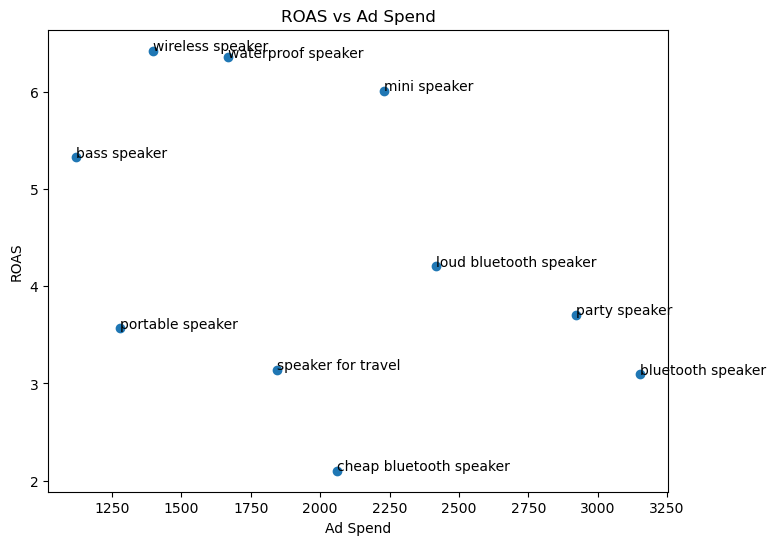

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(keyword_summary["Spend"], keyword_summary["ROAS"])

for i, txt in enumerate(keyword_summary.index):
    plt.annotate(txt, (keyword_summary["Spend"][i], keyword_summary["ROAS"][i]))

plt.xlabel("Ad Spend")
plt.ylabel("ROAS")

plt.title("ROAS vs Ad Spend")

plt.show()

## Key Insights

Top Performing Keywords:
- wireless speaker
- mini speaker
- waterproof speaker

These keywords show strong conversion rates and high ROAS.

Underperforming Keyword:
- cheap bluetooth speaker

This keyword has the lowest conversion rate and lowest ROAS.

Recommendations:
- Increase bids for high-performing keywords
- Reduce or pause underperforming keywords

In [23]:
df.to_csv("amazon_ads_data.csv", index=False)